# BusterNet Validation Diagnostics

Validation-split notebook for Einar's DINO-BusterNet checkpoints. It rebuilds the same validation split, caches prediction probabilities once, reports forged/authentic diagnostics, and plots examples. Do not use the reserved local holdout split here.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "einar_busternet").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)


/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle


## Configuration

`ALLOW_TORCH_HUB` must be `True` before the model is rebuilt. This is intentional because model construction uses official DINO through `torch.hub` and may initialize cached DINO assets.

In [2]:
CHECKPOINT_CHOICE = "last"  # "best", "last", or "custom"
CUSTOM_CHECKPOINT_PATH = None
CHECKPOINT_PATHS = {
    "best": Path("einar_busternet/artifacts/checkpoints/best.pt"),
    "last": Path("einar_busternet/artifacts/checkpoints/last.pt"),
}
CHECKPOINT_PATH = Path(CUSTOM_CHECKPOINT_PATH) if CHECKPOINT_CHOICE == "custom" else CHECKPOINT_PATHS[CHECKPOINT_CHOICE]

DEVICE = "auto"
ALLOW_TORCH_HUB = True
VAL_SUBSET = None
BATCH_SIZE = None
VALIDATION_TRANSFER_MODE = None  # None uses checkpoint config, usually "accumulate_gpu"
THRESHOLD_FOR_TABLES = None      # None uses config.pred_threshold

# Keep this notebook light. Set lists below to try a few alternatives.
MAX_SWEEP_SETTINGS = 5
PRED_THRESHOLDS = None
MIN_COMPONENT_AREAS = None
CONFIDENT_THRESHOLDS = None
SMOOTH_OPTIONS = None
OPENING_OPTIONS = None
CLOSING_OPTIONS = None
FILL_HOLES_OPTIONS = None
KEEP_CONFIDENT_SEEDED_OPTIONS = None


In [3]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from dataset_utils import list_labeled_samples
from datasets.splits import make_grouped_stratified_splits
from engine.checkpointing import load_checkpoint
from engine.validation_inference import collect_validation_predictions, score_validation_predictions, _post_process_probability
from engine.validation_records import load_resized_instance_masks
from evaluate_validation_postprocess import iter_postprocess_settings
from einar_busternet.evaluate import (
    _build_val_loader,
    _resolve_device,
    config_from_checkpoint,
    validate_model_loading_allowed,
)
from einar_busternet.model import BusterNetUnionWrapper
from einar_busternet.train import _build_sliding_window_fn, build_model
from inference.postprocess import post_process_prediction
from util.pixelmapUtil import PixelMapUtil
from visualization import ForgeryDataPlotter


## Load Checkpoint And Validation Split

In [4]:
validate_model_loading_allowed(ALLOW_TORCH_HUB)
if CHECKPOINT_CHOICE not in {"best", "last", "custom"}:
    raise ValueError(f"CHECKPOINT_CHOICE must be 'best', 'last', or 'custom', got {CHECKPOINT_CHOICE!r}")
if CHECKPOINT_CHOICE == "custom" and CUSTOM_CHECKPOINT_PATH is None:
    raise ValueError("CUSTOM_CHECKPOINT_PATH must be set when CHECKPOINT_CHOICE='custom'")

device = _resolve_device(DEVICE)
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location=device, trusted=True)
config = config_from_checkpoint(checkpoint)
if VAL_SUBSET is not None:
    config = type(config)(**{**config.__dict__, "val_subset": VAL_SUBSET})
if BATCH_SIZE is not None:
    config = type(config)(**{**config.__dict__, "batch_size": BATCH_SIZE})
if VALIDATION_TRANSFER_MODE is not None:
    config = type(config)(**{**config.__dict__, "validation_transfer_mode": VALIDATION_TRANSFER_MODE})

all_samples = list_labeled_samples(Path(config.data_root))
splits = make_grouped_stratified_splits(
    all_samples,
    seed=config.seed,
    train_ratio=config.train_ratio,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)
val_samples = splits["val"]
if config.val_subset is not None:
    val_samples = val_samples[: config.val_subset]

print(f"device={device}")
print(f"checkpoint_choice={CHECKPOINT_CHOICE}")
print(f"checkpoint={CHECKPOINT_PATH}")
print(f"checkpoint_epoch={checkpoint.get('epoch')}")
print(f"stored_kaggle_score={checkpoint.get('kaggle_score')}")
print(f"validation samples={len(val_samples)}")
print(f"batch_size={config.val_batch_size or config.batch_size}, transfer={config.validation_transfer_mode}")


device=cuda
checkpoint_choice=last
checkpoint=einar_busternet/artifacts/checkpoints/last.pt
checkpoint_epoch=15
stored_kaggle_score=0.48236247403556465
validation samples=514
batch_size=32, transfer=accumulate_gpu


## Cache Validation Predictions

This is the expensive cell. After it runs, the rest of the notebook reuses cached probability maps.

In [5]:
model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
wrapped_model = BusterNetUnionWrapper(model, eps=config.union_wrapper_eps)

val_loader = _build_val_loader(config, val_samples, device)
predictions = collect_validation_predictions(
    model=wrapped_model,
    val_loader=val_loader,
    val_samples=val_samples,
    device=device,
    inference_mode=config.validation_inference_mode,
    sliding_window_fn=_build_sliding_window_fn(config),
    probability_dtype=config.validation_probability_dtype,
    collect_masks=config.compute_pixel_f1,
    transfer_mode=config.validation_transfer_mode,
)
len(predictions)


Using cache found in /home/einar/.cache/torch/hub/facebookresearch_dinov2_main


514

## Overall Score

In [6]:
pixel_util = PixelMapUtil()
score_result = score_validation_predictions(
    predictions=predictions,
    pixel_util=pixel_util,
    pred_threshold=config.pred_threshold,
    harden_temperature=config.harden_temperature,
    hard_clip_low=config.hard_clip_low,
    hard_clip_high=config.hard_clip_high,
    min_component_area=config.min_component_area,
    compute_pixel_f1=config.compute_pixel_f1,
    verify_score_equivalence=config.verify_score_equivalence,
    confident_threshold=config.post_process_confident_threshold,
    smooth_probabilities=config.post_process_smooth_probabilities,
    fill_holes=config.post_process_fill_holes,
    apply_opening=config.post_process_apply_opening,
    apply_closing=config.post_process_apply_closing,
    keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
)
score_result


{'kaggle_score': 0.48236247403556465,
 'pixel_f1': None,
 'num_samples': 514,
 'num_forged': 276,
 'num_authentic': 238,
 'postprocess_seconds': 5.79490877599892,
 'scoring_seconds': 0.058776054000190925}

## Tiny Post-Processing Sweep

This reuses cached probabilities and tries at most `MAX_SWEEP_SETTINGS` settings. Keep it small for quick diagnosis; use the baseline sweep notebook if you want a larger post-processing search.

In [7]:
sweep_args = SimpleNamespace(
    pred_thresholds=PRED_THRESHOLDS or [config.pred_threshold],
    min_component_areas=MIN_COMPONENT_AREAS or [config.min_component_area],
    confident_thresholds=CONFIDENT_THRESHOLDS or [config.post_process_confident_threshold],
    smooth_options=SMOOTH_OPTIONS or [config.post_process_smooth_probabilities],
    opening_options=OPENING_OPTIONS or [config.post_process_apply_opening],
    closing_options=CLOSING_OPTIONS or [config.post_process_apply_closing],
    fill_holes_options=FILL_HOLES_OPTIONS or [config.post_process_fill_holes],
    keep_confident_seeded_options=KEEP_CONFIDENT_SEEDED_OPTIONS or [config.post_process_keep_confident_seeded_components],
    max_settings=MAX_SWEEP_SETTINGS,
)

sweep_rows = []
for rank, setting in enumerate(iter_postprocess_settings(config, sweep_args), start=1):
    result = score_validation_predictions(
        predictions=predictions,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        compute_pixel_f1=setting["compute_pixel_f1"],
        verify_score_equivalence=setting["verify_score_equivalence"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )
    sweep_rows.append({"rank": rank, **setting, **result})

sweep_df = pd.DataFrame(sweep_rows).sort_values("kaggle_score", ascending=False)
sweep_df


,rank,pred_threshold,min_component_area,confident_threshold,smooth_probabilities,apply_opening,apply_closing,fill_holes,keep_confident_seeded_components,harden_temperature,...,hard_clip_high,compute_pixel_f1,verify_score_equivalence,kaggle_score,pixel_f1,num_samples,num_forged,num_authentic,postprocess_seconds,scoring_seconds
0,1,0.5,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.482362,None,514,276,238,5.66446,0.055672


## Per-Sample Diagnostics

Authentic rows expose false positives. Forged rows expose empty predictions, missed GT area, predicted area ratio, and pixel IoU/F1 for quick debugging.

In [8]:
def gt_union_for_prediction(prediction):
    shape = prediction.probability.shape
    instances = load_resized_instance_masks(prediction.sample, shape)
    if not instances:
        return np.zeros(shape, dtype=np.uint8)
    gt = np.zeros(shape, dtype=np.uint8)
    for instance in instances:
        gt = np.maximum(gt, (instance > 0).astype(np.uint8))
    return gt


def pred_mask_for_prediction(prediction, threshold=None):
    threshold = config.pred_threshold if threshold is None else threshold
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=threshold,
        harden_temperature=config.harden_temperature,
        hard_clip_low=config.hard_clip_low,
        hard_clip_high=config.hard_clip_high,
        min_component_area=config.min_component_area,
        confident_threshold=config.post_process_confident_threshold,
        smooth_probabilities=config.post_process_smooth_probabilities,
        fill_holes=config.post_process_fill_holes,
        apply_opening=config.post_process_apply_opening,
        apply_closing=config.post_process_apply_closing,
        keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
    )


def pixel_stats(pred_bin, gt_bin):
    pred = pred_bin > 0
    gt = gt_bin > 0
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    union = tp + fp + fn
    precision = tp / (tp + fp) if tp + fp else 1.0 if gt.sum() == 0 else 0.0
    recall = tp / (tp + fn) if tp + fn else 1.0 if pred.sum() == 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    iou = tp / union if union else 1.0
    return tp, fp, fn, precision, recall, f1, iou

rows = []
threshold = config.pred_threshold if THRESHOLD_FOR_TABLES is None else THRESHOLD_FOR_TABLES
for idx, prediction in enumerate(predictions):
    pred_bin = pred_mask_for_prediction(prediction, threshold=threshold)
    gt_bin = gt_union_for_prediction(prediction)
    tp, fp, fn, precision, recall, f1, iou = pixel_stats(pred_bin, gt_bin)
    rows.append({
        "idx": idx,
        "sample_id": prediction.sample.sample_id,
        "case_id": prediction.sample.case_id,
        "label": prediction.sample.label,
        "gt_pixels": int(gt_bin.sum()),
        "pred_pixels": int(pred_bin.sum()),
        "fp_pixels": fp,
        "fn_pixels": fn,
        "precision": precision,
        "recall": recall,
        "pixel_f1": f1,
        "pixel_iou": iou,
        "max_prob": float(np.max(prediction.probability)),
        "mean_prob": float(np.mean(prediction.probability)),
        "p99_prob": float(np.quantile(prediction.probability, 0.99)),
        "pred_empty": int(pred_bin.sum() == 0),
        "gt_empty": int(gt_bin.sum() == 0),
    })

diagnostic_df = pd.DataFrame(rows)
diagnostic_df.head()


/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:127: RuntimeWarning: overflow encountered in cast
  'get_virtual_index': lambda n, quantiles: (n - 1) * quantiles,
/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4767: RuntimeWarning: overflow encountered in cast
  indexes_above_bounds = virtual_indexes >= valid_values_count - 1
/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4673: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4674: RuntimeWarning: invalid value encountered in scalar multiply
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, w

,idx,sample_id,case_id,label,gt_pixels,pred_pixels,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
0,0,authentic:10030,10030,authentic,0,1490,1490,0,0.00000,0.000000,0.000000,0.000000,0.930176,0.031281,NaN,0,1
1,1,forged:10030,10030,forged,13868,11567,4285,6586,0.62955,0.525094,0.572597,0.401146,0.961426,0.079346,NaN,0,0
2,2,authentic:10277,10277,authentic,0,0,0,0,1.00000,1.000000,1.000000,1.000000,0.146240,0.006248,NaN,1,1
3,3,forged:10277,10277,forged,19782,3579,0,16203,1.00000,0.180922,0.306408,0.180922,0.962402,0.039948,NaN,0,0
4,4,authentic:10730,10730,authentic,0,0,0,0,1.00000,1.000000,1.000000,1.000000,0.039703,0.003487,NaN,1,1


In [9]:
summary = diagnostic_df.groupby("label").agg(
    samples=("sample_id", "count"),
    mean_pred_pixels=("pred_pixels", "mean"),
    median_pred_pixels=("pred_pixels", "median"),
    total_fp_pixels=("fp_pixels", "sum"),
    empty_prediction_rate=("pred_empty", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_pixel_iou=("pixel_iou", "mean"),
    mean_max_prob=("max_prob", "mean"),
    mean_p99_prob=("p99_prob", "mean"),
).reset_index()
summary


,label,samples,mean_pred_pixels,median_pred_pixels,total_fp_pixels,empty_prediction_rate,mean_pixel_f1,mean_pixel_iou,mean_max_prob,mean_p99_prob
0,authentic,238,120.953782,0.0,28787,0.932773,0.932773,0.932773,0.222573,NaN
1,forged,276,2150.344203,0.0,96070,0.659420,0.128597,0.086716,0.437577,NaN


In [10]:
authentic_fp = diagnostic_df.query("label == 'authentic'").sort_values(["pred_pixels", "max_prob"], ascending=False)
forged_misses = diagnostic_df.query("label == 'forged'").sort_values(["pixel_f1", "recall", "pred_pixels"], ascending=[True, True, True])
forged_big_fp = diagnostic_df.query("label == 'forged'").sort_values("fp_pixels", ascending=False)

print("Worst authentic false positives")
display(authentic_fp.head(10))
print("Worst forged misses")
display(forged_misses.head(10))
print("Forged with most FP pixels")
display(forged_big_fp.head(10))


Worst authentic false positives


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
503,503,authentic:7759,7759,authentic,0,4384,4384,0,0.0,0.0,0.0,0.0,0.954590,0.098938,NaN,0,1
110,110,authentic:21706,21706,authentic,0,4345,4345,0,0.0,0.0,0.0,0.0,0.821289,0.078247,NaN,0,1
343,343,authentic:48880,48880,authentic,0,2714,2714,0,0.0,0.0,0.0,0.0,0.825684,0.066040,NaN,0,1
464,464,authentic:62793,62793,authentic,0,2475,2475,0,0.0,0.0,0.0,0.0,0.935059,0.030869,NaN,0,1
89,89,authentic:19467,19467,authentic,0,2441,2441,0,0.0,0.0,0.0,0.0,0.960938,0.018173,NaN,0,1
118,118,authentic:22821,22821,authentic,0,2358,2358,0,0.0,0.0,0.0,0.0,0.873047,0.031281,NaN,0,1
236,236,authentic:36553,36553,authentic,0,1993,1993,0,0.0,0.0,0.0,0.0,0.943359,0.019470,NaN,0,1
210,210,authentic:3167,3167,authentic,0,1592,1592,0,0.0,0.0,0.0,0.0,0.823242,0.035645,NaN,0,1
0,0,authentic:10030,10030,authentic,0,1490,1490,0,0.0,0.0,0.0,0.0,0.930176,0.031281,NaN,0,1
122,122,authentic:22864,22864,authentic,0,1426,1426,0,0.0,0.0,0.0,0.0,0.819336,0.023407,NaN,0,1


Worst forged misses


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
7,7,forged:10884,10884,forged,75744,0,0,75744,0.0,0.0,0.0,0.0,0.377686,0.073242,NaN,1,0
11,11,forged:11010,11010,forged,479,0,0,479,0.0,0.0,0.0,0.0,0.119263,0.007652,NaN,1,0
15,15,forged:11299,11299,forged,17708,0,0,17708,0.0,0.0,0.0,0.0,0.437500,0.061005,NaN,1,0
17,17,forged:11747,11747,forged,813,0,0,813,0.0,0.0,0.0,0.0,0.274658,0.018112,NaN,1,0
19,19,forged:11904,11904,forged,3877,0,0,3877,0.0,0.0,0.0,0.0,0.312988,0.009346,NaN,1,0
21,21,forged:11954,11954,forged,1074,0,0,1074,0.0,0.0,0.0,0.0,0.187622,0.033722,NaN,1,0
23,23,forged:12046,12046,forged,552,0,0,552,0.0,0.0,0.0,0.0,0.173096,0.007572,NaN,1,0
29,29,forged:13254,13254,forged,2068,0,0,2068,0.0,0.0,0.0,0.0,0.053894,0.007942,NaN,1,0
33,33,forged:13986,13986,forged,113,0,0,113,0.0,0.0,0.0,0.0,0.045441,0.008560,NaN,1,0
34,34,forged:14111,14111,forged,626,0,0,626,0.0,0.0,0.0,0.0,0.324707,0.009163,NaN,1,0


Forged with most FP pixels


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
111,111,forged:21706,21706,forged,29647,22282,6532,13897,0.706849,0.531251,0.606597,0.435335,0.967285,0.158203,NaN,0,0
486,486,forged:64589,64589,forged,7820,11005,5379,2194,0.511222,0.719437,0.597716,0.426244,0.971191,0.057648,NaN,0,0
490,490,forged:64971,64971,forged,19459,14189,4709,9979,0.668123,0.487178,0.563481,0.392254,0.970215,0.084290,NaN,0,0
90,90,forged:19467,19467,forged,21929,22768,4514,3675,0.801739,0.832414,0.816789,0.690315,0.968750,0.116516,NaN,0,0
1,1,forged:10030,10030,forged,13868,11567,4285,6586,0.629550,0.525094,0.572597,0.401146,0.961426,0.079346,NaN,0,0
304,304,forged:42827,42827,forged,21191,13627,3986,11550,0.707492,0.454957,0.553794,0.382929,0.964844,0.088562,NaN,0,0
469,469,forged:63257,63257,forged,38398,18514,3903,23787,0.789187,0.380515,0.513459,0.345406,0.957520,0.109192,NaN,0,0
237,237,forged:36553,36553,forged,14354,6933,3130,10551,0.548536,0.264944,0.357307,0.217513,0.933594,0.048828,NaN,0,0
404,404,forged:54945,54945,forged,12117,7944,3051,7224,0.615937,0.403813,0.487812,0.322587,0.965332,0.045746,NaN,0,0
504,504,forged:7759,7759,forged,42211,10393,2645,34463,0.745502,0.183554,0.294578,0.172731,0.932129,0.145874,NaN,0,0


## Probability Distributions

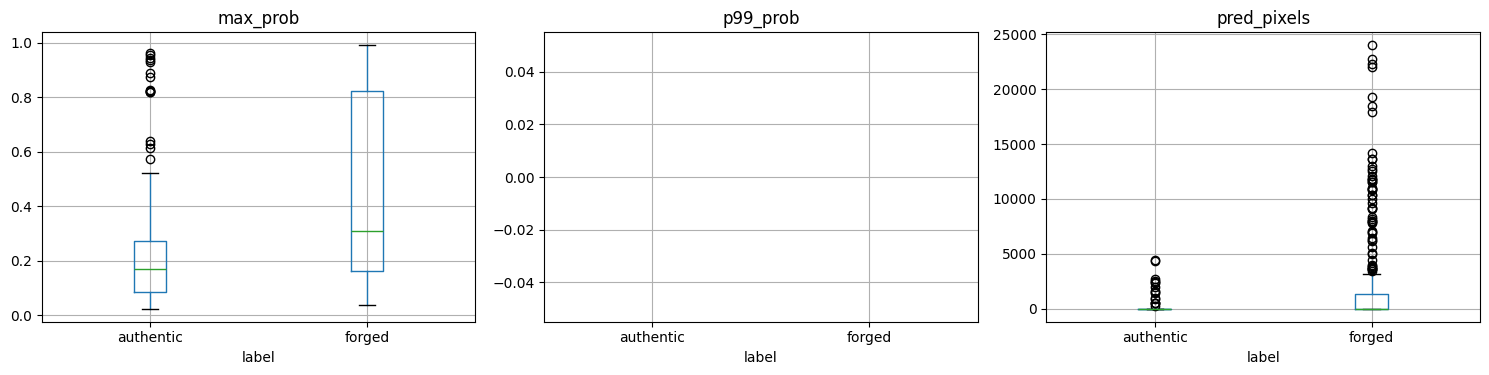

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
diagnostic_df.boxplot(column="max_prob", by="label", ax=axes[0])
diagnostic_df.boxplot(column="p99_prob", by="label", ax=axes[1])
diagnostic_df.boxplot(column="pred_pixels", by="label", ax=axes[2])
for ax in axes:
    ax.set_title(ax.get_title().replace(" by label", ""))
fig.suptitle("")
fig.tight_layout()


## Plot Examples

Authentic false positives


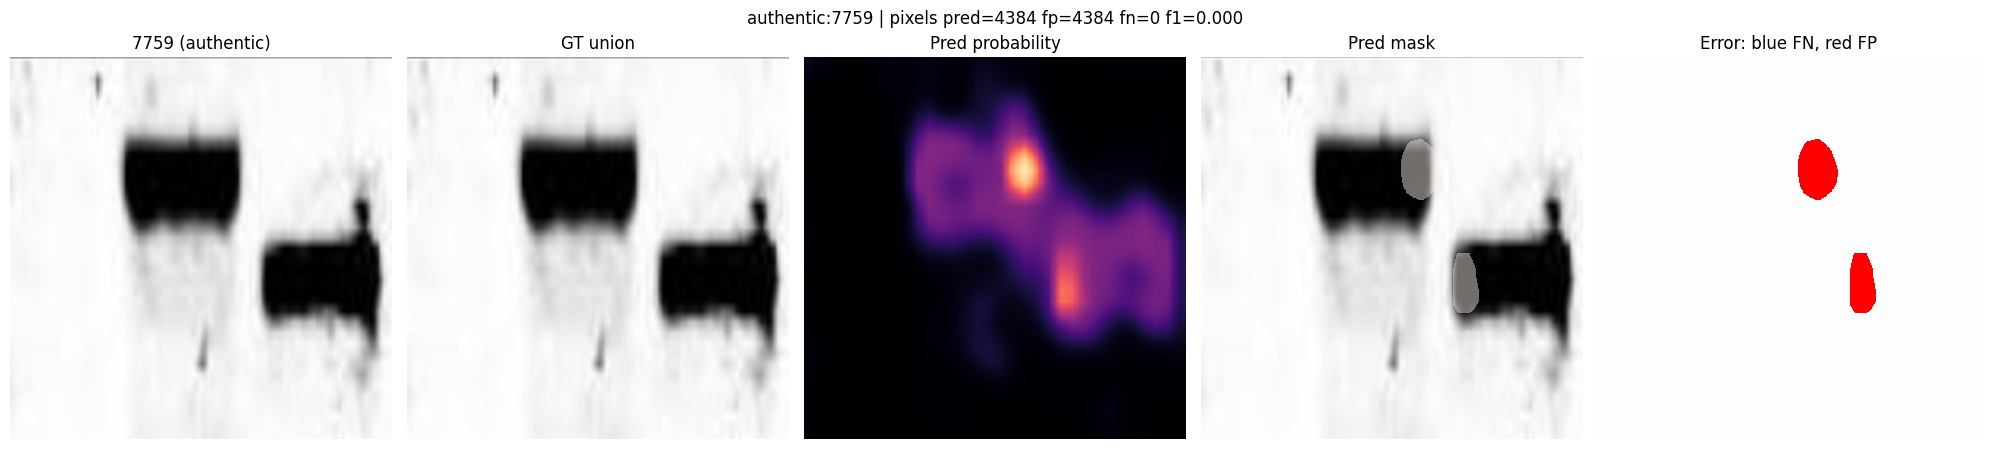

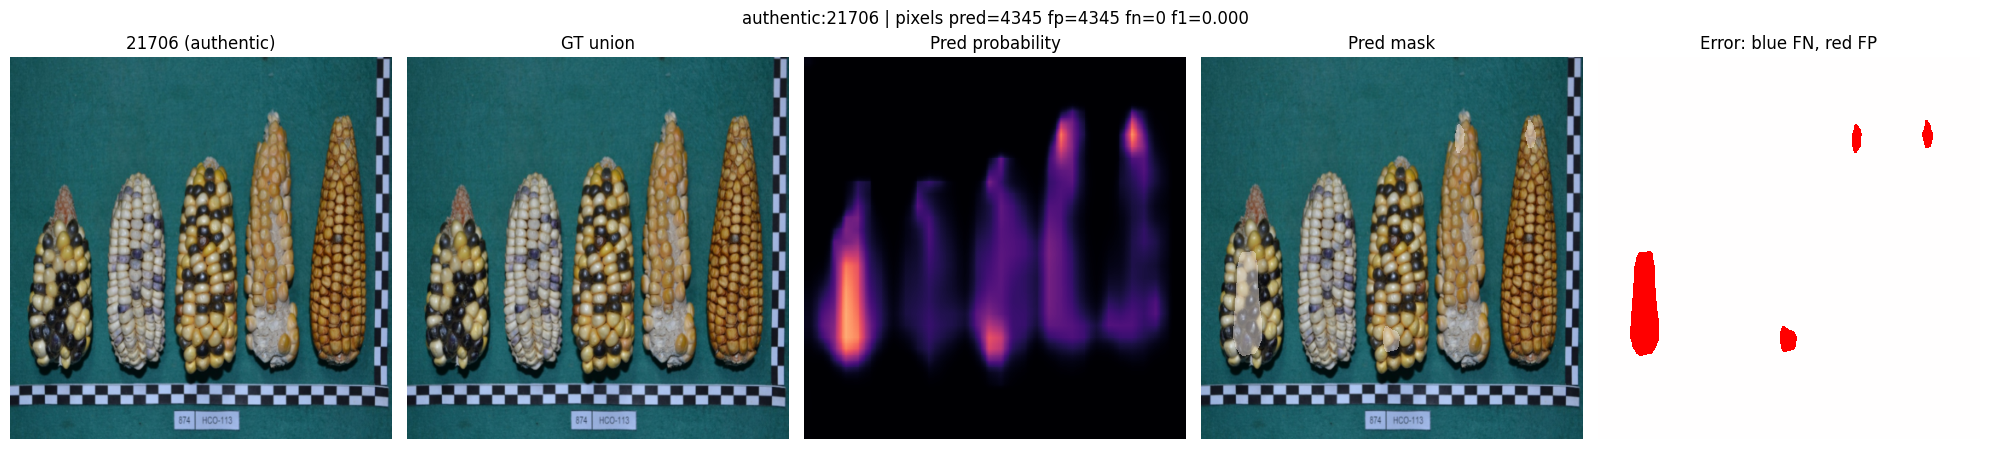

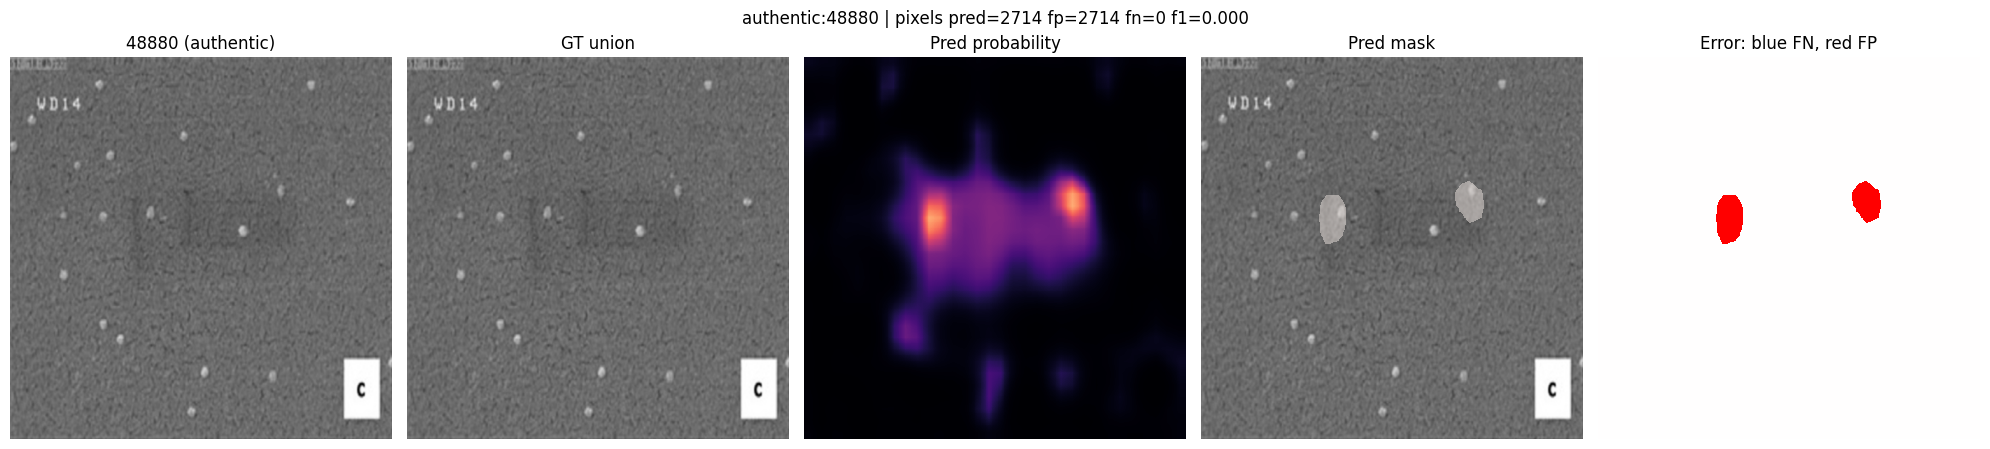

Forged misses


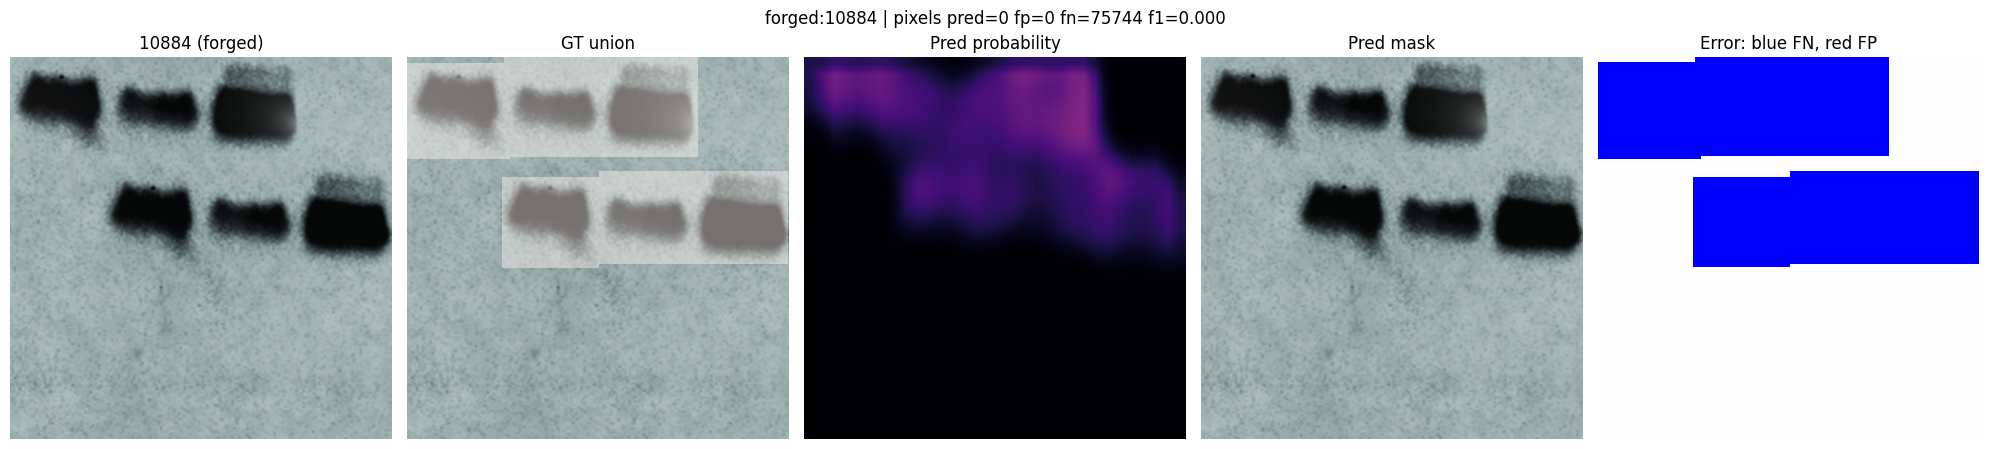

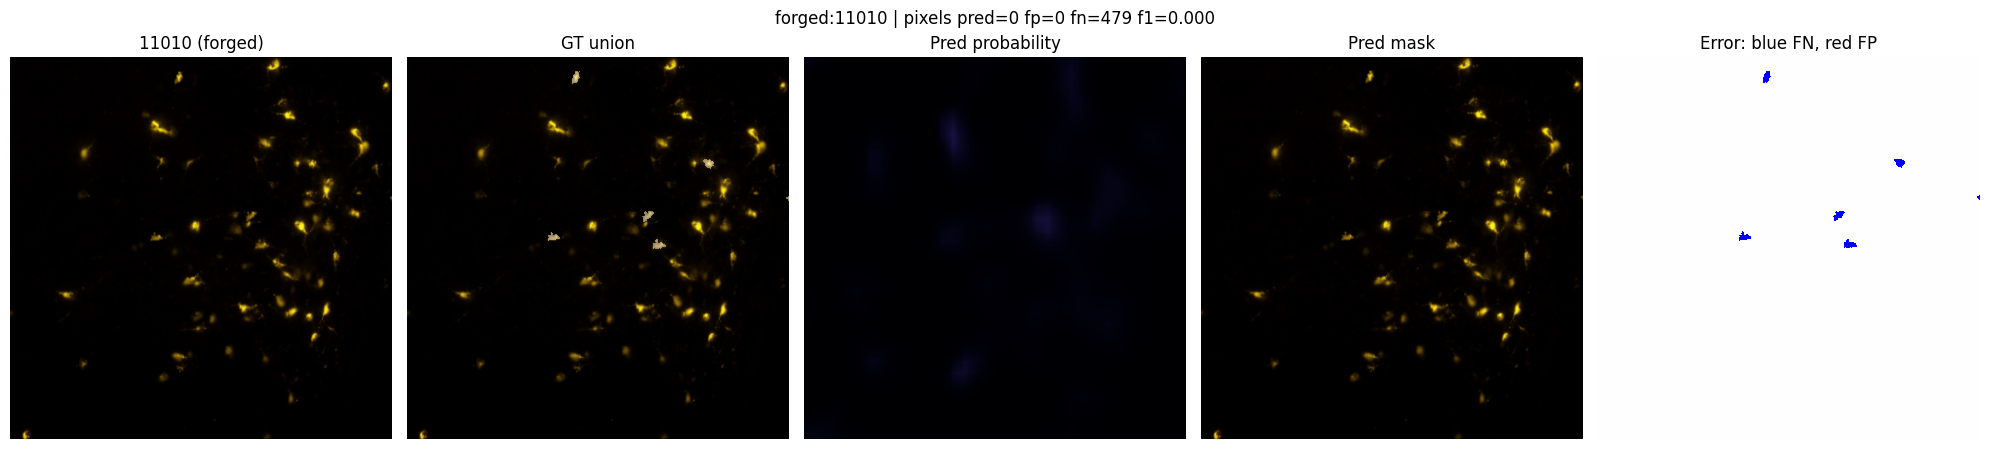

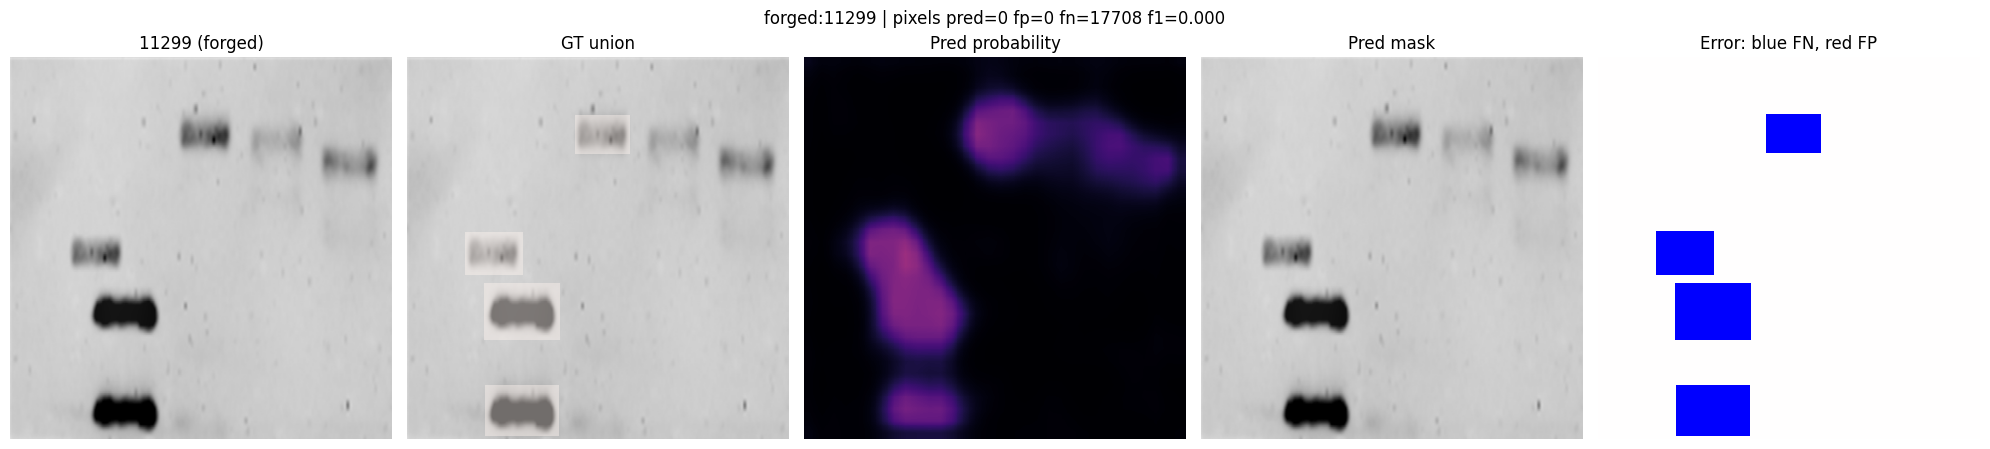

Forged successes


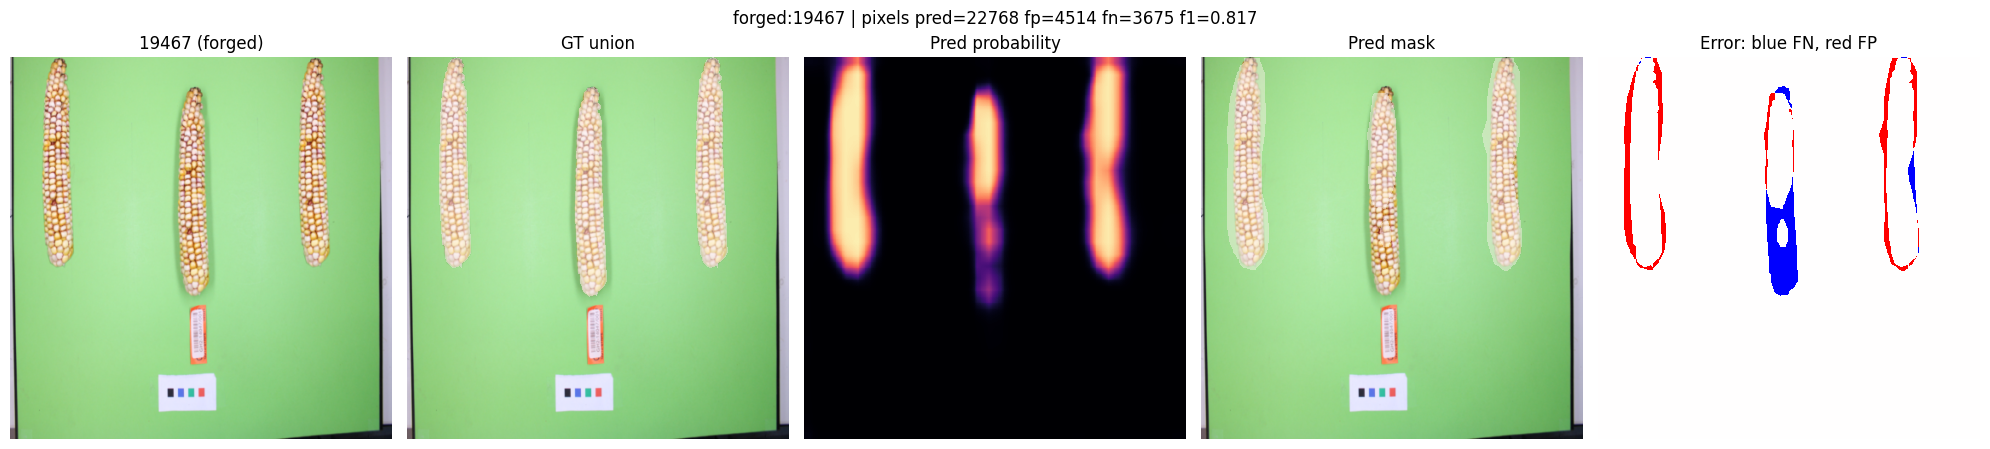

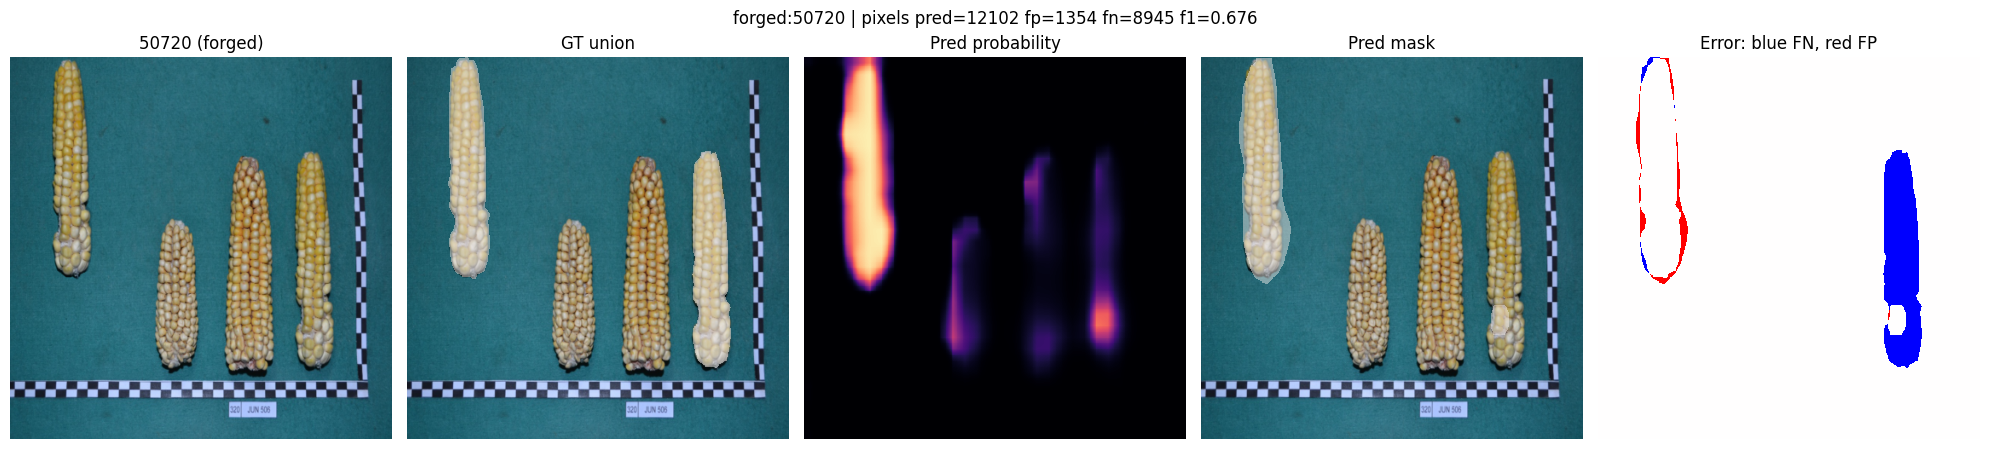

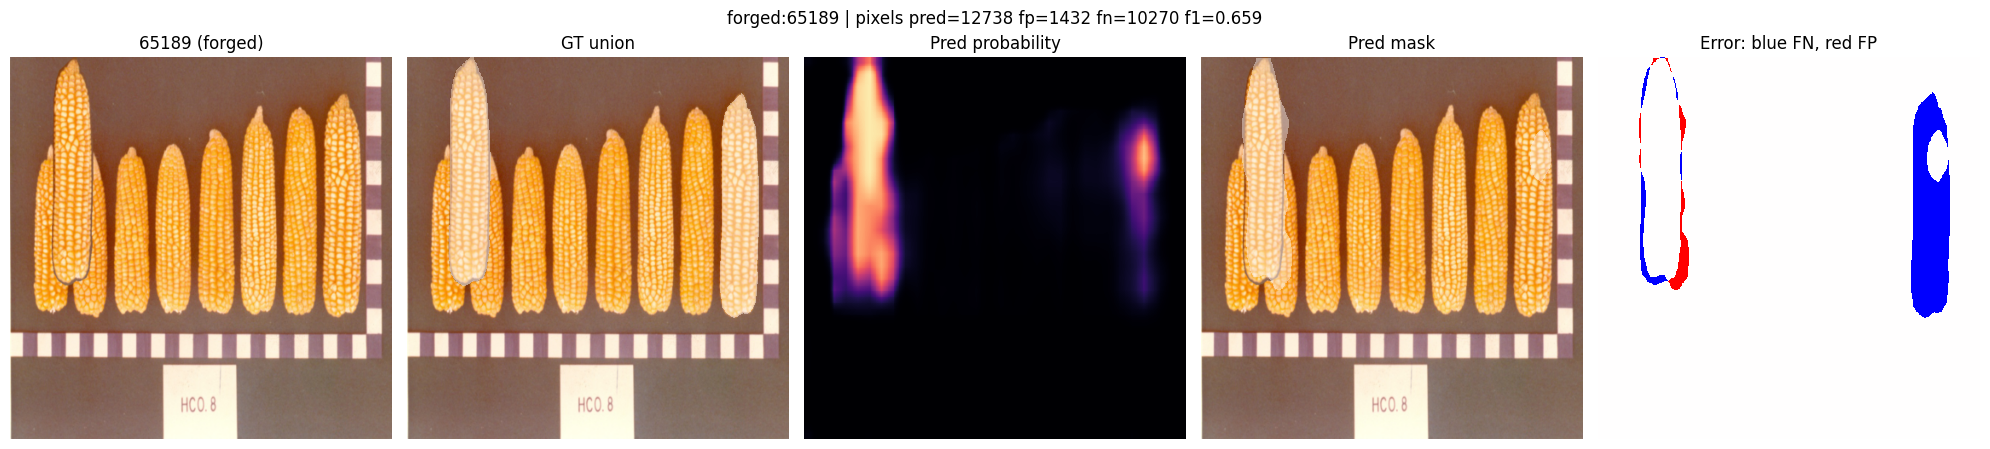

Authentic clean examples


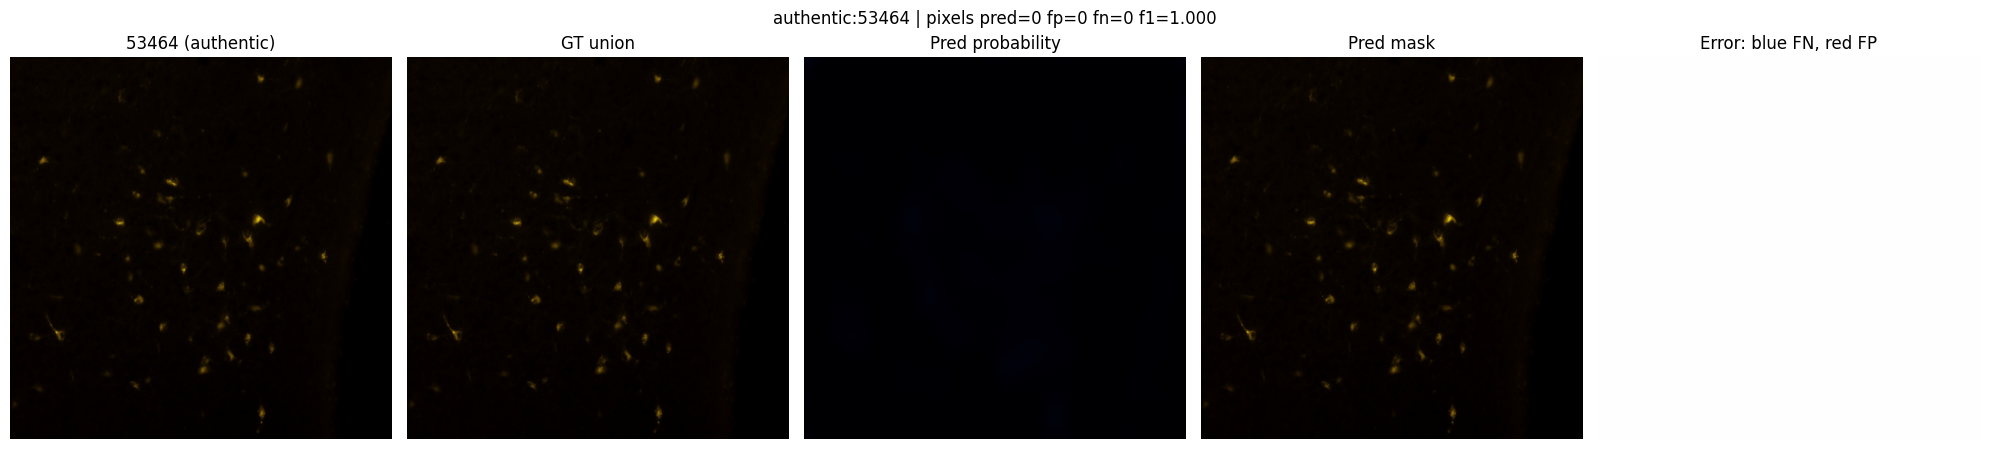

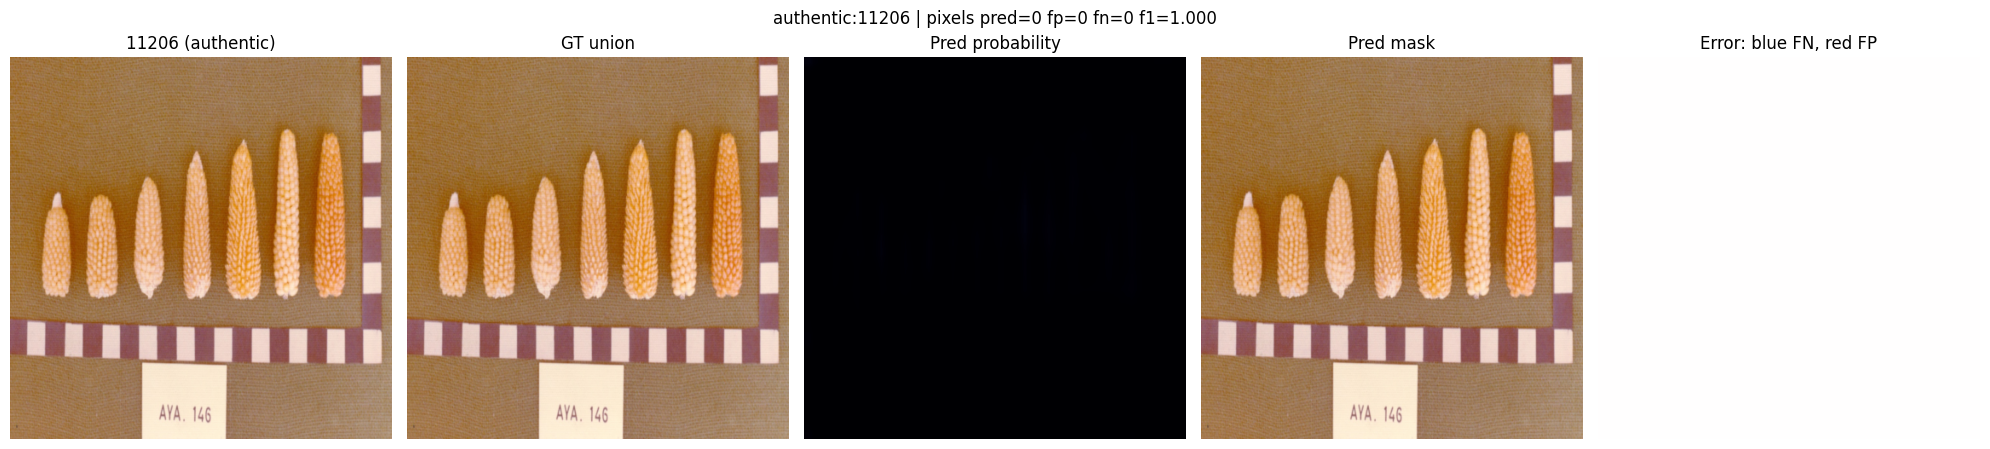

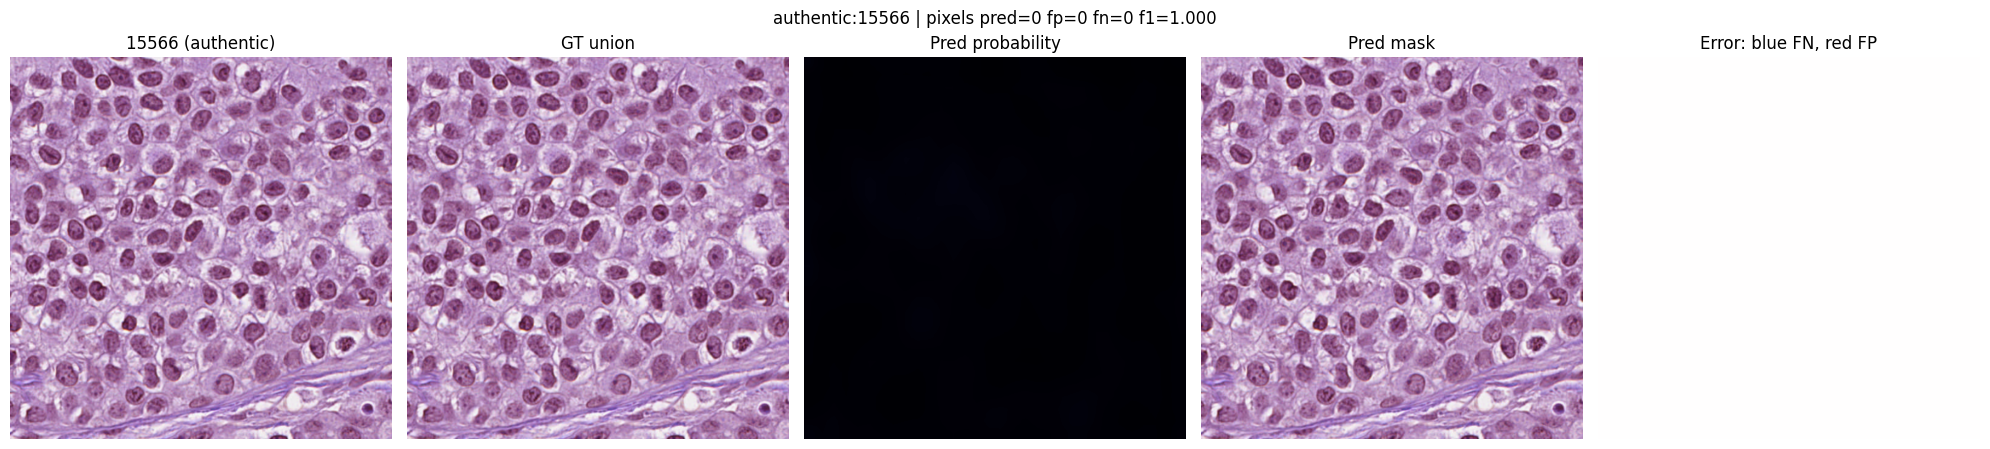

Random validation examples


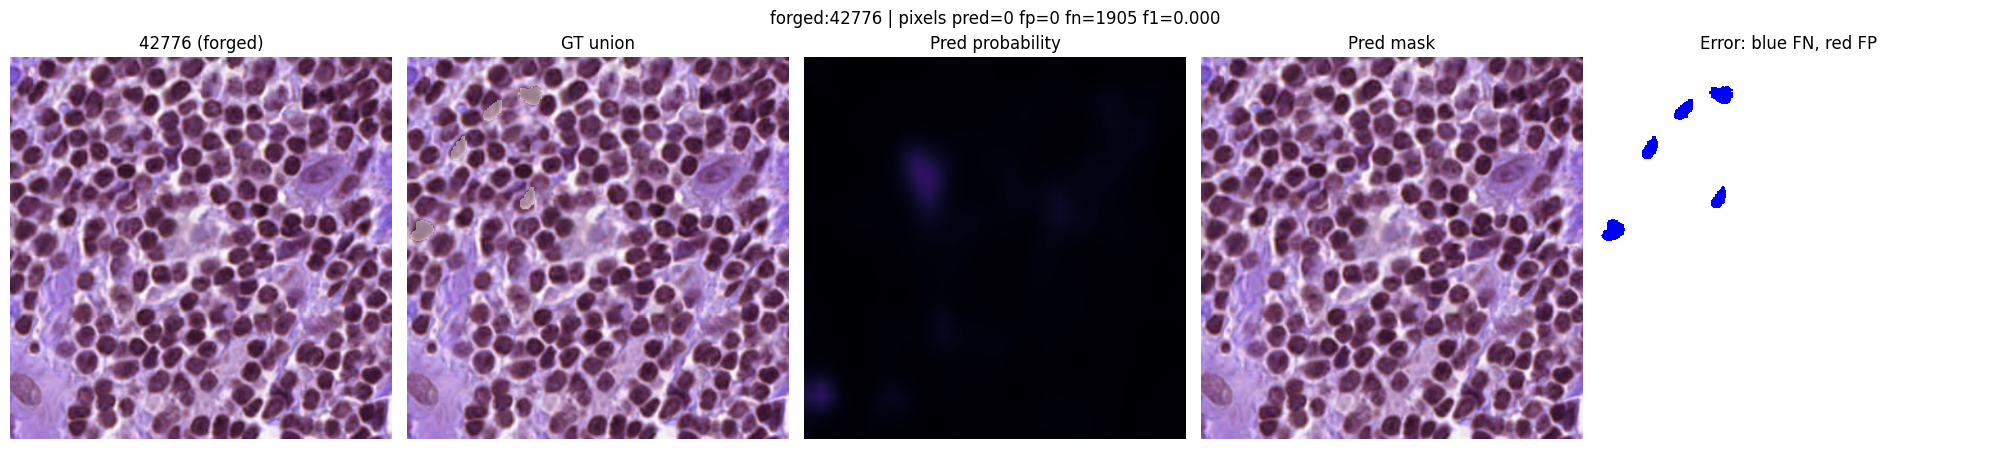

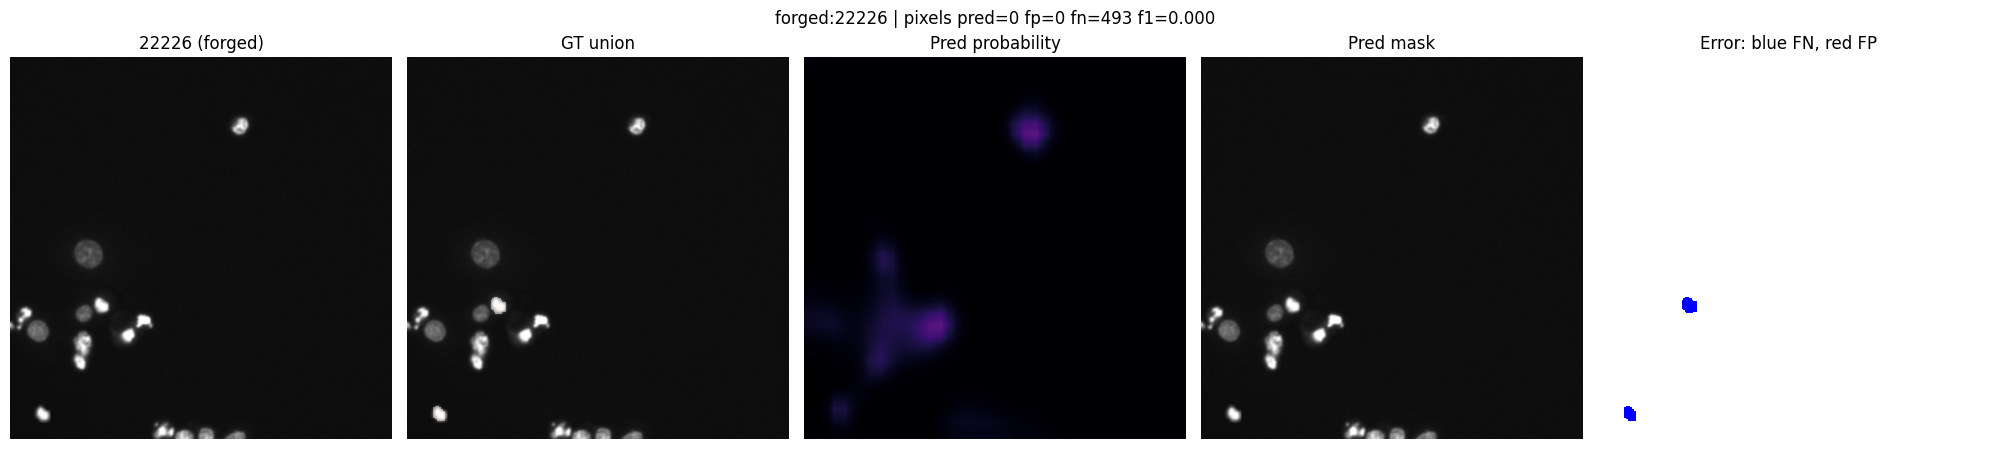

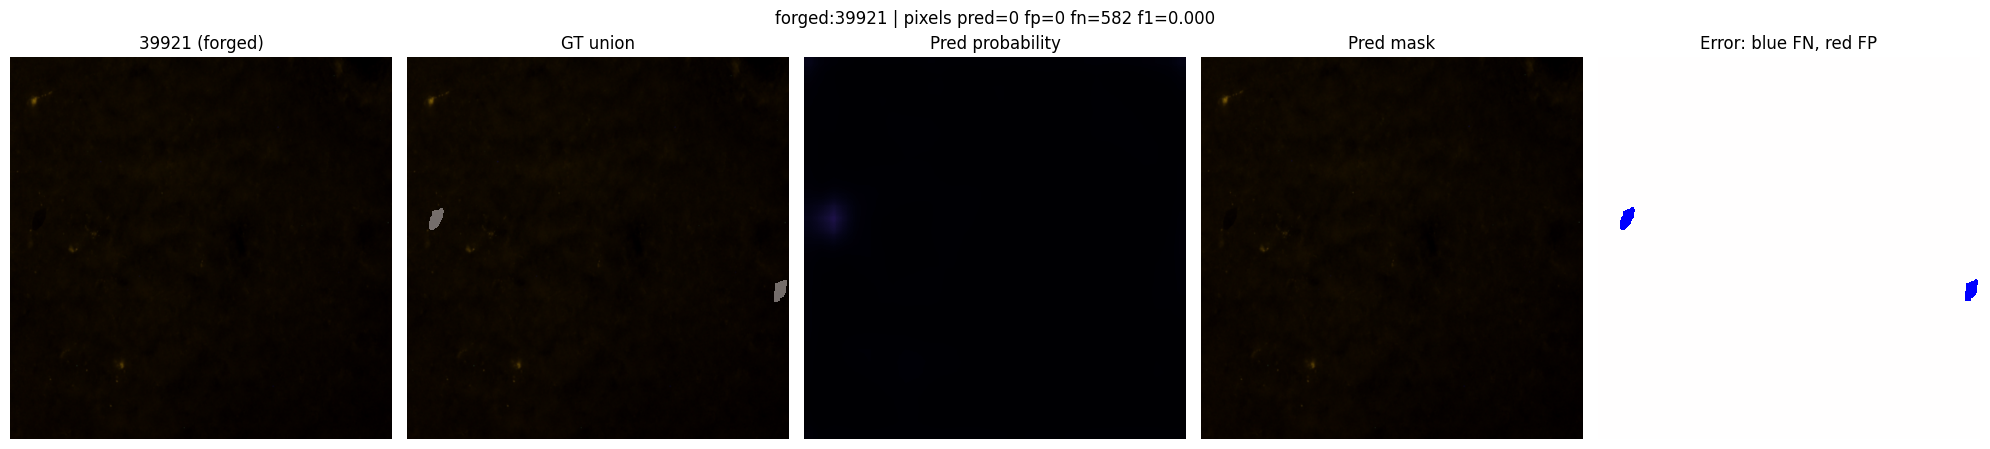

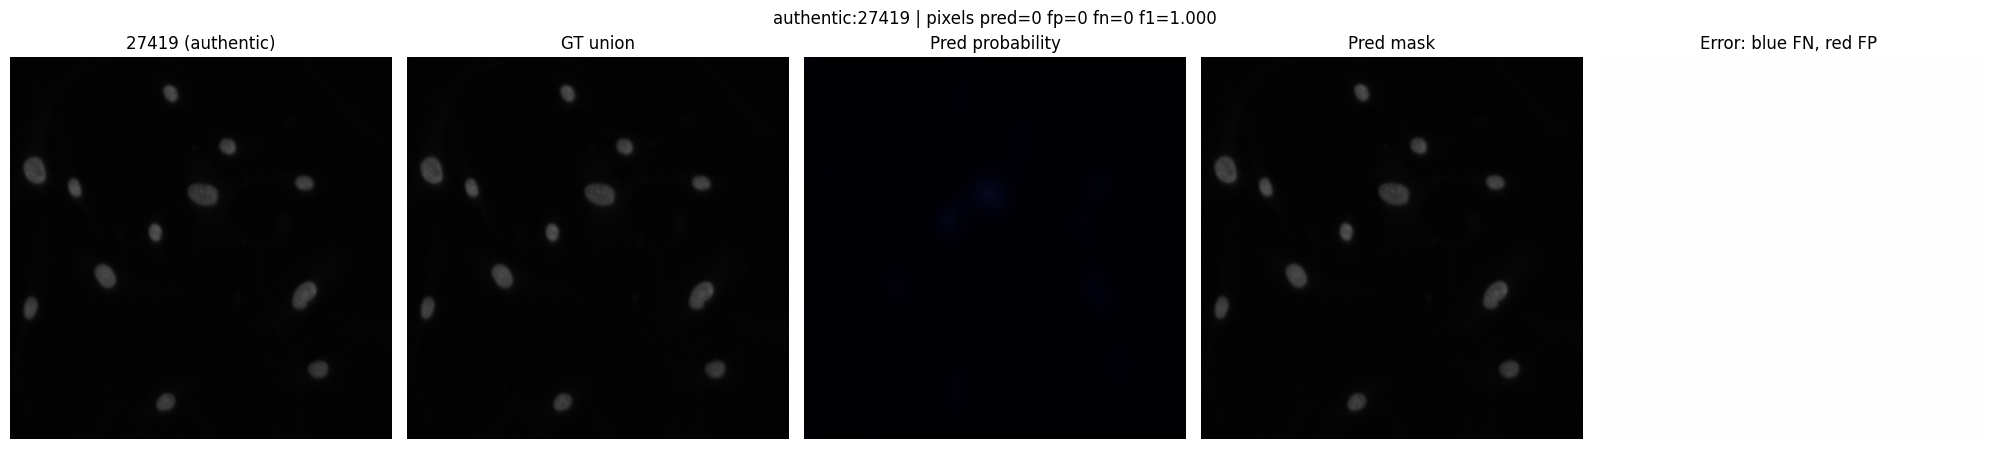

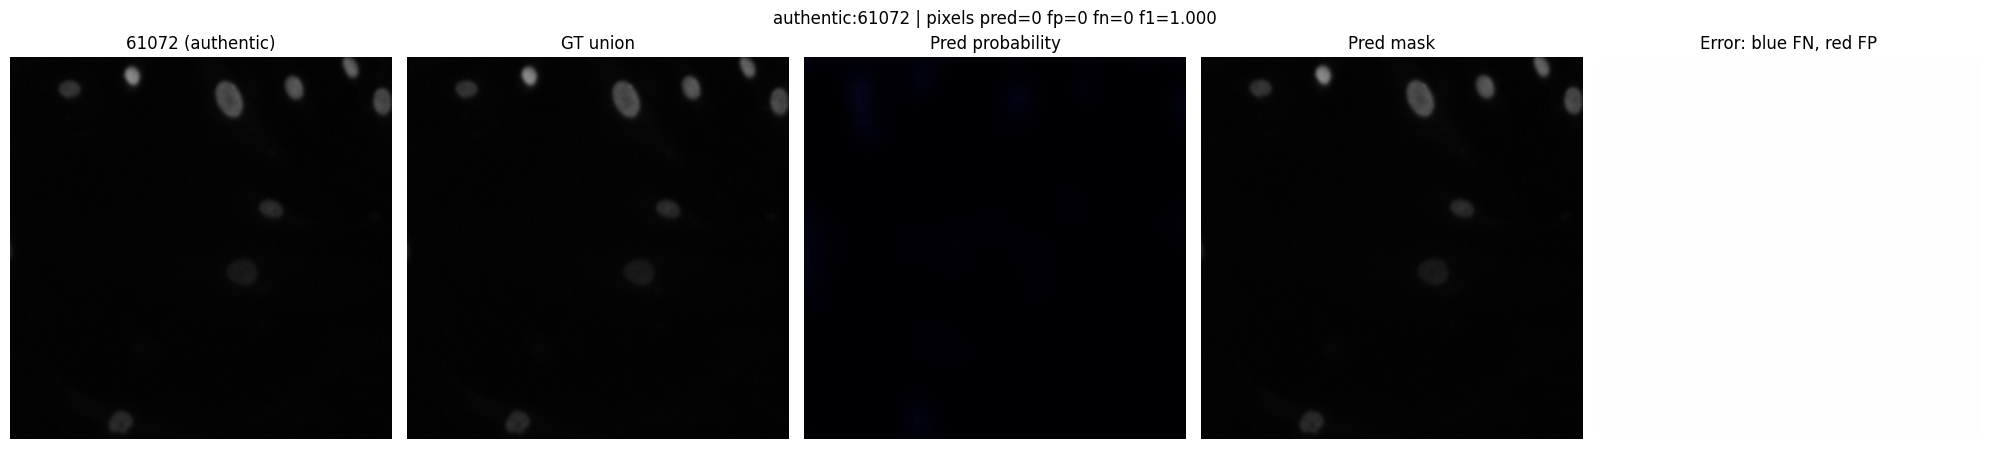

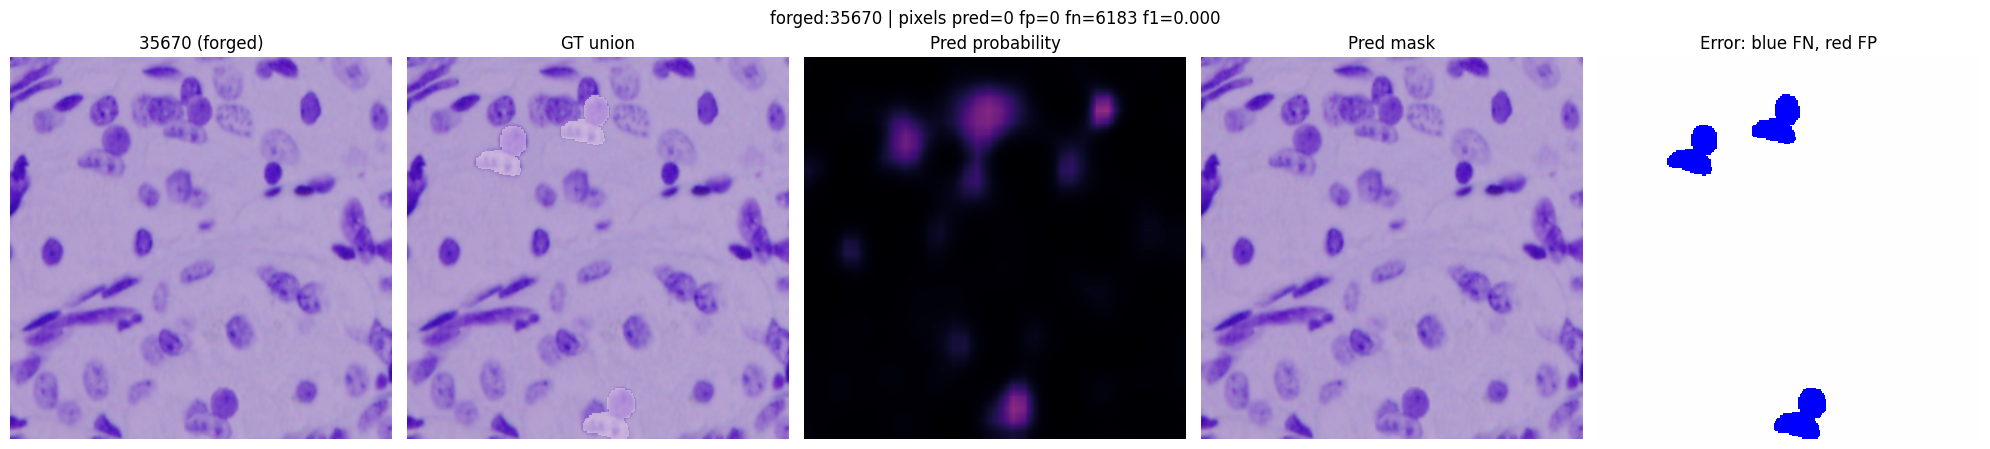

In [12]:
plotter = ForgeryDataPlotter(config.data_root)


def plot_rows(df, n=3, title=""):
    print(title)
    if len(df) == 0:
        print("No rows to plot.")
        return
    for _, row in df.head(n).iterrows():
        prediction = predictions[int(row.idx)]
        pred_bin = pred_mask_for_prediction(prediction, threshold=threshold)
        fig, axes = plotter.plot_prediction(prediction.sample, prediction.probability, pred_mask=pred_bin, threshold=threshold)
        fig.suptitle(
            f"{row.sample_id} | pixels pred={row.pred_pixels} fp={row.fp_pixels} fn={row.fn_pixels} f1={row.pixel_f1:.3f}",
            y=1.03,
        )
        plt.show()

forged_successes = diagnostic_df.query("label == 'forged' and pred_pixels > 0").sort_values(
    ["pixel_f1", "recall", "precision"], ascending=[False, False, False]
)
authentic_clean = diagnostic_df.query("label == 'authentic'").sort_values(
    ["pred_pixels", "max_prob"], ascending=[True, True]
)
random_examples = diagnostic_df.sample(n=min(6, len(diagnostic_df)), random_state=7)

plot_rows(authentic_fp, n=3, title="Authentic false positives")
plot_rows(forged_misses, n=3, title="Forged misses")
plot_rows(forged_successes, n=3, title="Forged successes")
plot_rows(authentic_clean, n=3, title="Authentic clean examples")
plot_rows(random_examples, n=6, title="Random validation examples")


## Save Diagnostics

In [13]:
output_dir = Path("einar_busternet/artifacts/results")
output_dir.mkdir(parents=True, exist_ok=True)
diagnostics_path = output_dir / "validation_diagnostics.csv"
summary_path = output_dir / "validation_diagnostics_summary.csv"
diagnostic_df.to_csv(diagnostics_path, index=False)
summary.to_csv(summary_path, index=False)
print(diagnostics_path)
print(summary_path)


einar_busternet/artifacts/results/validation_diagnostics.csv
einar_busternet/artifacts/results/validation_diagnostics_summary.csv


## Cleanup GPU Memory

Run this when you are done inspecting predictions. Restarting the notebook kernel also frees everything.

In [14]:
import gc

for name in [
    "model",
    "wrapped_model",
    "val_loader",
    "predictions",
]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"CUDA allocated after cleanup: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"CUDA reserved after cleanup: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
else:
    print("CUDA not available")


CUDA allocated after cleanup: 383.4 MB
CUDA reserved after cleanup: 604.0 MB
